In [18]:
import matplotlib.pyplot as plt
import numpy as np

You can enter resources you have access to for graphing purposes.

In [21]:
setups = [
    {"name": "RTX 3090 (Elysium)", "tflops": 71.0, "cost_hr": 0.00}
]

Architecture variables. Copy from GPTConfig in model.py before playing with this notebook to make sure they are up to date. If you update the architecture you will need to change how the calculations are done. If you are only playing with hyperparamets you shouldn't need to though.

In [22]:
# enter architecture variables here
depth = 12
block_size = 1024
vocab_size = 50304 # using the one in train.py here instead of model.py
n_layer = depth
n_head = depth
n_embd = depth * 64
mfu = 0.45 # model flop utilization

# calculate exact parameters
wte_params = vocab_size * n_embd # token embedding layer
wpe_params = block_size * n_embd # positional embedding layer
attn_params = (n_embd * 3 * n_embd) + (3 * n_embd) # c_attn weights and biases
attn_proj_params = (n_embd * n_embd) + n_embd # c_proj weights and biases
mlp_fc_params = (n_embd * 4 * n_embd) + (4 * n_embd)
mlp_proj_params = (4 * n_embd * n_embd) + n_embd
ln_params = 2 * n_embd
block_params = attn_params + attn_proj_params + mlp_fc_params + mlp_proj_params + (2 * ln_params)

# note: lm_head weights are tied to wte, which is why they aren't counted
total_params = wte_params + wpe_params + (n_layer * block_params) + ln_params
print(f"total model parameters is {total_params // 1000000}M")
 

total model parameters is 124M


Apply Chinchilla Scaling Laws. Chinchilla paper suggests 20 tokens per parameter for compute-optimal training.

In [29]:
def calc_metrics(params, tokens, tflops, mfu, cost_hr):
    total_flops = 6 * params * tokens
    achieved_flops_per_sec = (tflops * 1e12) * mfu
    hours = (total_flops / achieved_flops_per_sec) / 3600
    cost = hours * cost_hr
    return hours, cost

chinchilla_tokens = 20 * total_params
overtrain_5B = 5000000000
overtrain_10B = 10000000000

for setup in setups:
    h_chin, c_chin = calc_metrics(total_params, chinchilla_tokens, setup['tflops'], mfu, setup['cost_hr'])
    h_5b, c_5b = calc_metrics(total_params, overtrain_5B, setup['tflops'], mfu, setup['cost_hr'])
    h_10b, c_10b = calc_metrics(total_params, overtrain_10B, setup['tflops'], mfu, setup['cost_hr'])
    
    print(f"\n[{setup['name']}]")
    print(f"  Chinchilla (2.5B): {h_chin:.1f} hrs | ${c_chin:.2f}")
    print(f"  Overtrain  (5.0B): {h_5b:.1f} hrs | ${c_5b:.2f}")
    print(f"  Heavy      (10B):  {h_10b:.1f} hrs | ${c_10b:.2f}")


[RTX 3090 (Elysium)]
  Chinchilla (2.5B): 16.2 hrs | $0.00
  Overtrain  (5.0B): 32.5 hrs | $0.00
  Heavy      (10B):  64.9 hrs | $0.00


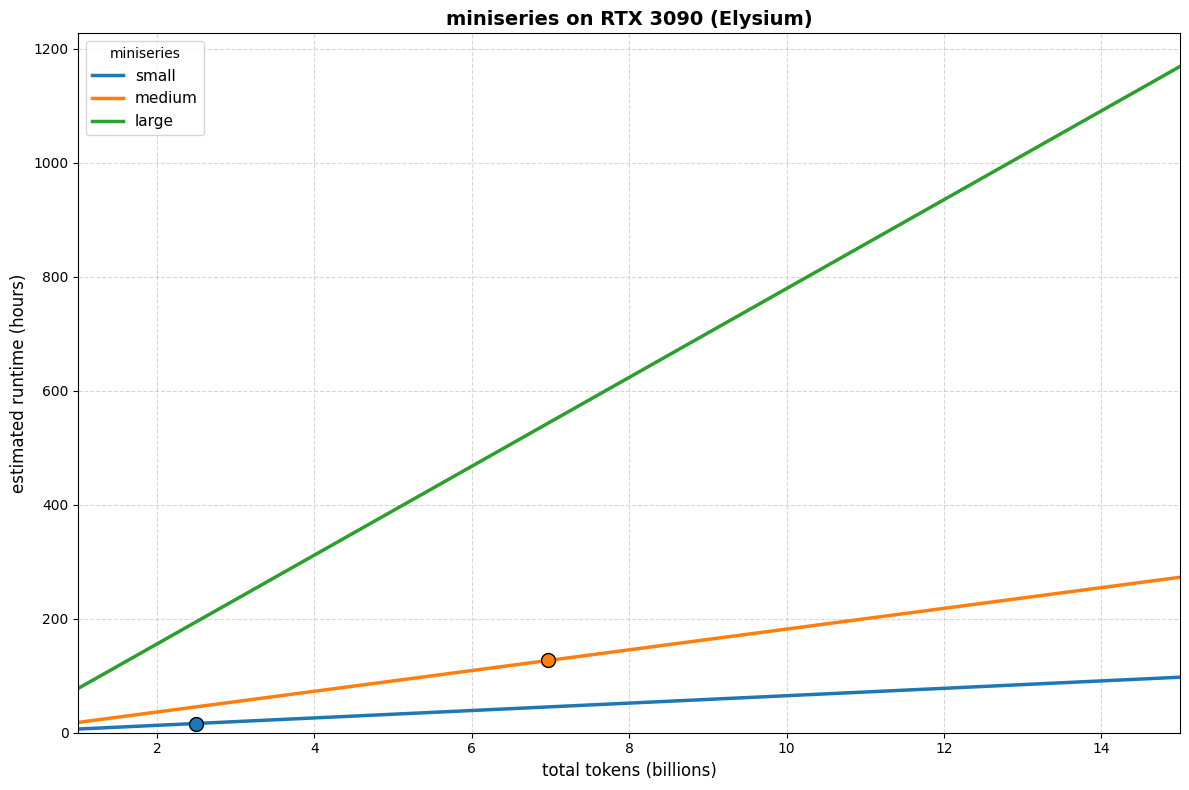

In [40]:
model_sizes = {
    "small": total_params,
    "medium": total_params * 2.8,
    "large": total_params * 12
}
token_range = np.linspace(1000000000, 15000000000, 100)
plt.figure(figsize=(12, 8))
target_setup = setups[0] 
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for i, (model_name, params) in enumerate(model_sizes.items()):
    times_hours = [calc_metrics(params, t, target_setup['tflops'], mfu, target_setup['cost_hr'])[0] for t in token_range]
    plt.plot(token_range / 1000000000, times_hours, label=f'{model_name}', color=colors[i], linewidth=2.5)
    chin_tokens = 20 * params
    if chin_tokens <= 15000000000:
        chin_time = calc_metrics(params, chin_tokens, target_setup['tflops'], mfu, target_setup['cost_hr'])[0]
        plt.scatter([chin_tokens/1e9], [chin_time], color=colors[i], s=100, zorder=5, edgecolor='black')
plt.title(f'miniseries on {target_setup["name"]}', fontsize=14, fontweight='bold')
plt.xlabel('total tokens (billions)', fontsize=12)
plt.ylabel('estimated runtime (hours)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(1, 15)
plt.ylim(0)
plt.legend(fontsize=11, title="miniseries")
plt.tight_layout()
plt.show()